In [ ]:
#PREPROCESSING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.decomposition import PCA

In [ ]:
import pandas as pd

df = pd.read_csv("/content/data penelitian stunting.csv")

df.head()

,Unnamed: 0,provinsi,Stunting (%),Underweight (%),Severe Wasting (%),Wasting (%),Overweight (%),pemberian ASI (%),pemberian MPASI (%),pemantauan pertumbuhan (%),pemberian vit.A (%),Pemberian imunisasi (%),akses air minum layak (%),akses sanitasi layak (%)
0,0,Aceh,"28,6","23,8","1,6",8,2,"94,8","75,2","67,9",83,"5,4","90,8","76,4"
1,1,Sumatera Utara,22,"17,6","2,1","6,9","2,3","89,9","74,5","54,5","63,4","27,6","90,6","79,5"
2,2,Sumatera Barat,"24,9","18,8","0,9","6,1","1,7","96,6","83,9","62,5","90,7","23,1","88,1","63,9"
3,3,Riau,"20,1","20,1","2,1","8,7","2,6",94,"77,1","45,5","67,7","27,2","92,4","75,3"
4,4,Jambi,"17,1","13,8","2,3","6,3","4,6","95,1","60,5","35,1","71,9","41,3","91,4","82,1"


In [ ]:
import pandas as pd

#PENGELOMPOKAN RISIKO STUNTING
def kategori_stunting(stunting):
    if stunting >= 30:
        return 'Risiko Tinggi'
    elif stunting >= 20:
        return 'Risiko Sedang'
    else:
        return 'Risiko Rendah'

# Convert 'Stunting (%)' to numeric, handling comma as decimal separator
# Only perform replacement if the column is of string type (object dtype)
if df['Stunting (%)'].dtype == 'object':
    df['Stunting (%)'] = df['Stunting (%)'].str.replace(',', '.', regex=False).astype(float)

df['stunting_group'] = df['Stunting (%)'].apply(kategori_stunting)

print(df['stunting_group'].value_counts())

stunting_group
Risiko Sedang    21
Risiko Rendah    12
Risiko Tinggi     5
Name: count, dtype: int64


In [ ]:
# Kategori Risiko Stunting
def kategori_stunting(stunting):
    if stunting >= 30:
        return 'Risiko Tinggi'
    elif stunting >= 20:
        return 'Risiko Sedang'
    else:
        return 'Risiko Rendah'

df['Stunting_Kategori'] = df['Stunting (%)'].apply(kategori_stunting)

print(df['Stunting_Kategori'].value_counts())

Stunting_Kategori
Risiko Sedang    21
Risiko Rendah    12
Risiko Tinggi     5
Name: count, dtype: int64


missing value

In [ ]:
df.isnull()

,Unnamed: 0,provinsi,Stunting (%),Underweight (%),Severe Wasting (%),Wasting (%),Overweight (%),pemberian ASI (%),pemberian MPASI (%),pemantauan pertumbuhan (%),pemberian vit.A (%),Pemberian imunisasi (%),akses air minum layak (%),akses sanitasi layak (%),stunting_group,Stunting_Kategori
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
np.sum(df.isnull())

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


,0
Unnamed: 0,0
provinsi,0
Stunting (%),0
Underweight (%),0
Severe Wasting (%),0
Wasting (%),0
Overweight (%),0
pemberian ASI (%),0
pemberian MPASI (%),0
pemantauan pertumbuhan (%),0


In [ ]:
df.isnull().sum().sum()

np.int64(0)

normalisasi data

In [ ]:
from sklearn.preprocessing import StandardScaler

# Pilih variabel yang akan dipakai untuk clustering
features = ['pemberian ASI (%)', 'pemberian MPASI (%)',
            'Pemberian imunisasi (%)', 'akses air minum layak (%)',
            'akses sanitasi layak (%)']

# Clean and convert selected feature columns to numeric
for col in features:
    # Ensure the column is treated as string first to use .str accessor
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    # Attempt to convert to float, coerce errors to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill any NaN values that resulted from conversion errors (e.g., '-' entries)
# For simplicity, filling with the mean of the column. Other strategies might be considered.
for col in features:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

X = df[features]

# Normalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])  # cek hasil normalisasi

[[ 0.66238197 -0.11748314 -2.53361311  0.44905385 -0.03468487]
 [-0.42758239 -0.18601497 -1.23052823  0.42204309  0.37710576]
 [ 1.06277703  0.73426963 -1.49466706  0.08440862 -1.69513096]
 [ 0.4844286   0.06853183 -1.25400724  0.66513991 -0.18080413]
 [ 0.72911448 -1.55665161 -0.42637224  0.53008612  0.72247854]]


encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode provinsi jadi angka
provinsi_encoder = LabelEncoder()
df['provinsi_encoded'] = provinsi_encoder.fit_transform(df['provinsi'])

print(df[['provinsi', 'provinsi_encoded']].head())

         provinsi  provinsi_encoded
0            Aceh                 0
1  Sumatera Utara                37
2  Sumatera Barat                35
3            Riau                29
4           Jambi                 7


CLUSTERING

In [ ]:
cluster_features = [
    'pemberian ASI (%)',
    'pemberian MPASI (%)',
    'Pemberian imunisasi (%)',
    'akses air minum layak (%)',
    'akses sanitasi layak (%)'
]

In [ ]:
X_cluster = df[cluster_features]

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

In [ ]:
from sklearn.cluster import KMeans

#Model K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("Silhouette Score :")
print(
    silhouette_score(X_scaled, df['cluster'])
)

print("\nDavies Bouldin Index :")
print(
    davies_bouldin_score(X_scaled, df['cluster'])
)

print("\nCalinski Harabasz Index :")
print(
    calinski_harabasz_score(X_scaled, df['cluster'])
)

Silhouette Score :
0.2919294096659549

Davies Bouldin Index :
1.2164129017643073

Calinski Harabasz Index :
17.18406879019623


In [ ]:
cluster_profile = df.groupby('cluster')[
    [
        'pemberian ASI (%)',
        'pemberian MPASI (%)',
        'Pemberian imunisasi (%)',
        'akses air minum layak (%)',
        'akses sanitasi layak (%)'
    ]
].mean()

print(cluster_profile)

         pemberian ASI (%)  pemberian MPASI (%)  Pemberian imunisasi (%)  \
cluster                                                                    
0                95.600000            89.075000                68.550000   
1                86.181818            65.909091                45.409091   
2                93.497076            77.136842                41.975146   

         akses air minum layak (%)  akses sanitasi layak (%)  
cluster                                                       
0                        95.575000                 71.087500  
1                        80.445455                 74.072727  
2                        88.134211                 80.506433  


In [ ]:
# K-Means clustering dengan 3 cluster
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

# Label risiko
cluster_mapping = {
    0: 'Risiko Rendah',
    1: 'Risiko Sedang',
    2: 'Risiko Tinggi'
}

df['Kategori_Risiko'] = df['Cluster'].map(cluster_mapping)

print(df[['provinsi', 'Cluster', 'Kategori_Risiko']])

                     provinsi  Cluster Kategori_Risiko
0                        Aceh        2   Risiko Tinggi
1              Sumatera Utara        2   Risiko Tinggi
2              Sumatera Barat        2   Risiko Tinggi
3                        Riau        2   Risiko Tinggi
4                       Jambi        2   Risiko Tinggi
5            Sumatera Selatan        2   Risiko Tinggi
6                    Bengkulu        2   Risiko Tinggi
7                     Lampung        2   Risiko Tinggi
8   Kepulauan Bangka Belitung        2   Risiko Tinggi
9              Kepulauan Riau        2   Risiko Tinggi
10                DKI Jakarta        0   Risiko Rendah
11                 Jawa Barat        0   Risiko Rendah
12                Jawa Tengah        0   Risiko Rendah
13              DI Yogyakarta        0   Risiko Rendah
14                 Jawa Timur        0   Risiko Rendah
15                     Banten        0   Risiko Rendah
16                       Bali        0   Risiko Rendah
17        

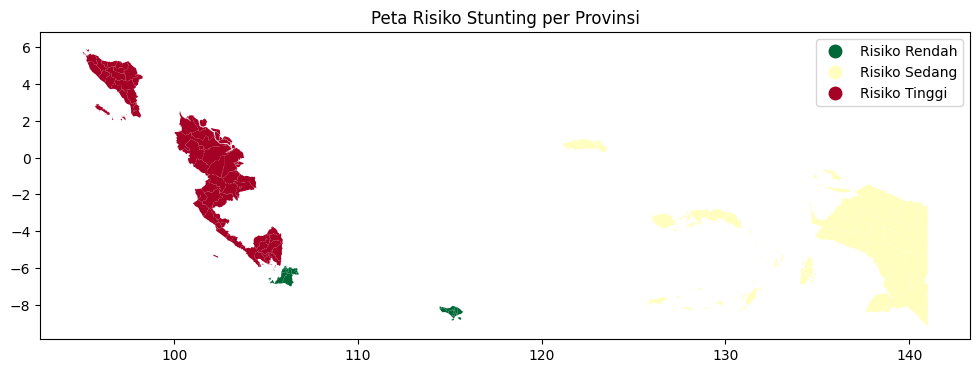

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Baca shapefile Indonesia level 1 (provinsi)
indo_map = gpd.read_file("/content/gadm41_IDN_2.json.zip")

# Gabungkan dengan hasil clustering
df_map = indo_map.merge(df, left_on="NAME_1", right_on="provinsi")

# Plot peta
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
df_map.plot(column="Kategori_Risiko",
            cmap="RdYlGn_r",  # hijau rendah, merah tinggi
            legend=True,
            ax=ax)

plt.title("Peta Risiko Stunting per Provinsi")

# Dictionary untuk samakan nama provinsi
nama_fix = {
    "West Java": "Jawa Barat",
    "Central Java": "Jawa Tengah",
    "Yogyakarta": "DI Yogyakarta",
    "East Java": "Jawa Timur",
    "Banten": "Banten",
    "Jakarta": "DKI Jakarta",
    "Bali": "Bali",
    "Central Kalimantan": "Kalimantan Tengah",
    "East Kalimantan": "Kalimantan Timur",
    "South Kalimantan": "Kalimantan Selatan",
    "North Kalimantan": "Kalimantan Utara",
    "West Kalimantan": "Kalimantan Barat",
    # tambahkan semua provinsi lain sesuai kebutuhan
}
indo_map["provinsi_fix"] = indo_map["NAME_1"].replace(nama_fix)
df_map = indo_map.merge(df, left_on="provinsi_fix", right_on="provinsi")

# Merge dengan dataframe hasil clustering
df_map = indo_map.merge(df, left_on="provinsi_fix", right_on="provinsi")
plt.show()

Peta risiko stunting per provinsi menunjukkan distribusi spasial tingkat risiko di seluruh Indonesia. Warna hijau, kuning, dan merah merepresentasikan kategori risiko rendah, sedang, dan tinggi berdasarkan hasil clustering K-Means dari variabel pemberian ASI, pemberian MPASI, imunisasi, akses air minum, dan sanitasi. Terlihat bahwa provinsi di Jawa dan Bali cenderung masuk kategori risiko rendah, sementara banyak provinsi di Sumatera, Kalimantan, dan sebagian Sulawesi masuk kategori risiko tinggi. Wilayah timur Indonesia seperti Nusa Tenggara dan Papua menunjukkan variasi dengan risiko sedang hingga tinggi. Peta ini menegaskan bahwa kondisi gizi dan lingkungan berperan besar dalam membentuk pola risiko stunting, namun batas antar kategori tidak sepenuhnya tegas sehingga tetap diperlukan analisis lebih lanjut melalui profil cluster untuk memahami karakteristik tiap kelompok secara mendalam.

In [ ]:
from sklearn.decomposition import PCA

# Visualisasi PCA Cluster
pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

df['PCA1'] = pca_result[:,0]
df['PCA2'] = pca_result[:,1]

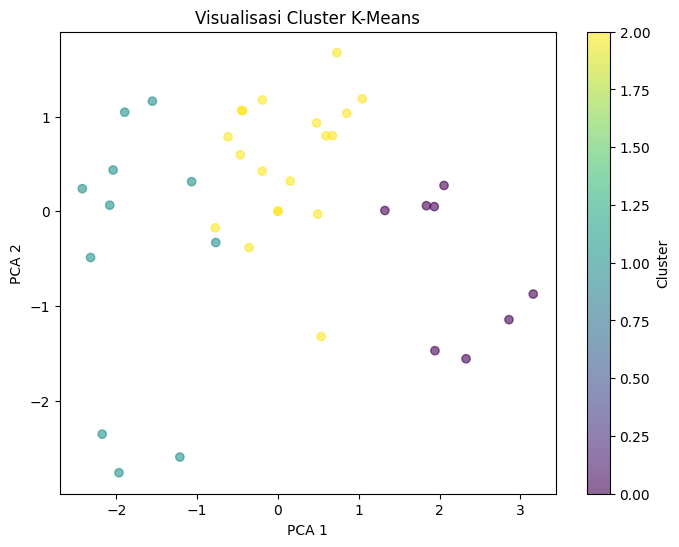

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(

    df['PCA1'],
    df['PCA2'],
    c=df['cluster'],
    alpha=0.6

)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Visualisasi Cluster K-Means")
plt.colorbar(label='Cluster')

plt.show()

Visualisasi PCA pada hasil K-Means membantu melihat pola kemiripan antar provinsi. Walaupun terlihat adanya pemisahan cluster risiko, masih terdapat banyak titik yang saling tumpang tindih (overlap). Hal ini menunjukkan bahwa faktor stunting dipengaruhi oleh berbagai variabel yang saling berkaitan. Dengan demikian, hasil clustering bukanlah batas absolut, melainkan indikasi kecenderungan risiko. PCA dan K-Means memberikan gambaran makro mengenai provinsi yang cenderung berisiko tinggi, sedang, atau rendah, namun tetap diperlukan analisis lebih lanjut melalui profil cluster (rata-rata ASI, MPASI, imunisasi, air minum, dan sanitasi) untuk interpretasi yang lebih mendalam. Visualisasi PCA ini hanya berfungsi sebagai representasi dua dimensi dari hasil clustering, bukan variabel tambahan, sehingga interpretasi utama tetap berdasarkan lima variabel inti.

In [ ]:
df['Cluster'] = kmeans.labels_

print(df[['provinsi', 'Cluster']])

                     provinsi  Cluster
0                        Aceh        2
1              Sumatera Utara        2
2              Sumatera Barat        2
3                        Riau        2
4                       Jambi        2
5            Sumatera Selatan        2
6                    Bengkulu        2
7                     Lampung        2
8   Kepulauan Bangka Belitung        2
9              Kepulauan Riau        2
10                DKI Jakarta        0
11                 Jawa Barat        0
12                Jawa Tengah        0
13              DI Yogyakarta        0
14                 Jawa Timur        0
15                     Banten        0
16                       Bali        0
17        Nusa Tenggara Barat        0
18        Nusa Tenggara Timur        1
19           Kalimantan Barat        2
20          Kalimantan Tengah        1
21         Kalimantan Selatan        2
22           Kalimantan Timur        2
23           Kalimantan Utara        2
24             Sulawesi U

In [ ]:
# Visualisasi PCA Cluster
pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

df['PCA1'] = pca_result[:,0]
df['PCA2'] = pca_result[:,1]

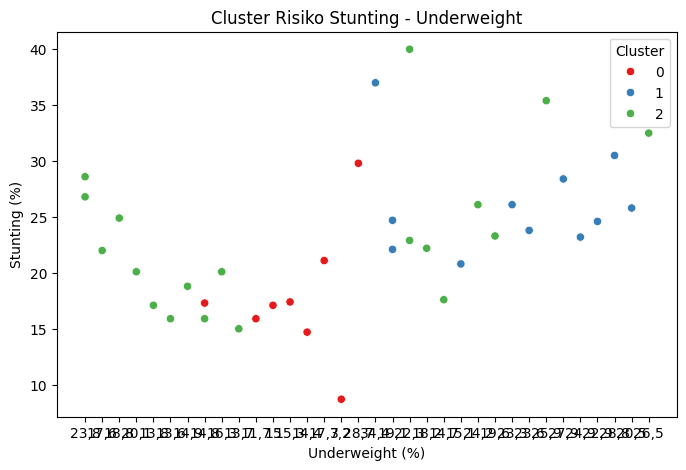

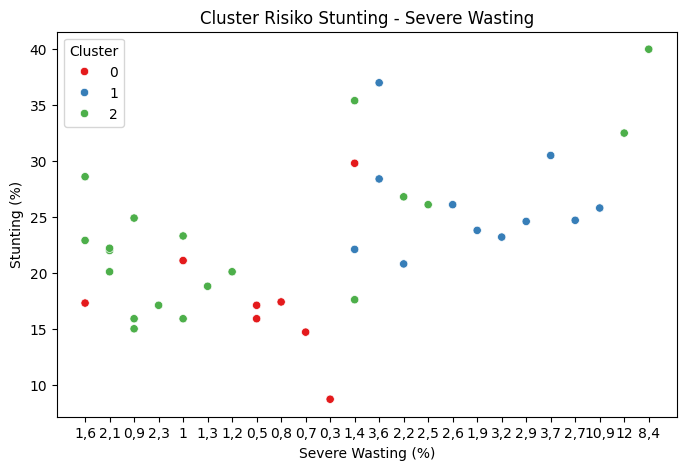

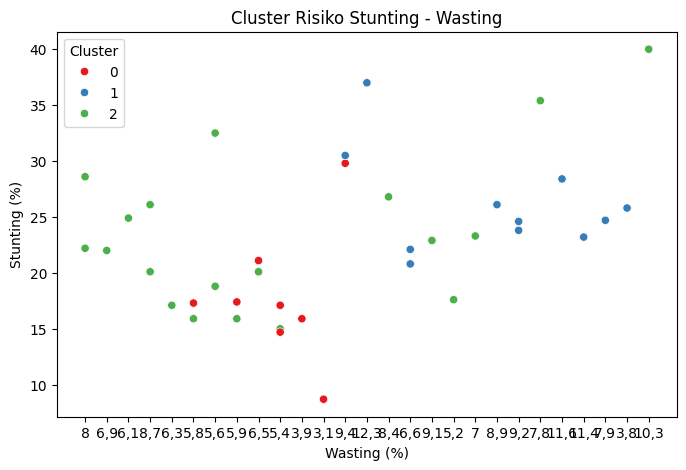

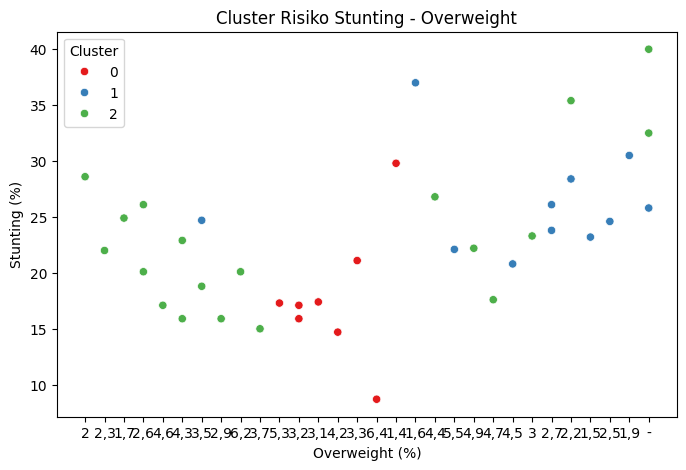

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Underweight vs Stunting
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['Underweight (%)'],
    y=df['Stunting (%)'],
    hue=df['Cluster'],
    palette='Set1'
)
plt.title('Cluster Risiko Stunting - Underweight')
plt.show()

# Severe Wasting vs Stunting
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['Severe Wasting (%)'],
    y=df['Stunting (%)'],
    hue=df['Cluster'],
    palette='Set1'
)
plt.title('Cluster Risiko Stunting - Severe Wasting')
plt.show()

# Wasting vs Stunting
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['Wasting (%)'],
    y=df['Stunting (%)'],
    hue=df['Cluster'],
    palette='Set1'
)
plt.title('Cluster Risiko Stunting - Wasting')
plt.show()

# Overweight vs Stunting
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['Overweight (%)'],
    y=df['Stunting (%)'],
    hue=df['Cluster'],
    palette='Set1'
)
plt.title('Cluster Risiko Stunting - Overweight')
plt.show()

Visualisasi scatter plot antara stunting dengan indikator gizi tambahan seperti underweight, severe wasting, wasting, dan overweight menunjukkan adanya pola korelasi yang beragam. Secara umum, provinsi dengan prevalensi underweight, wasting, maupun severe wasting yang tinggi cenderung memiliki angka stunting yang lebih tinggi dan masuk ke cluster risiko sedang hingga tinggi. Sementara itu, overweight tidak menunjukkan korelasi sekuat indikator gizi kurang, karena beberapa provinsi dengan angka overweight tinggi tetap berada di cluster risiko rendah. Meskipun terlihat adanya kecenderungan pola, batas antar cluster tidak sepenuhnya tegas, menandakan bahwa stunting dipengaruhi oleh banyak faktor gizi dan lingkungan, bukan hanya satu variabel. Oleh karena itu, visualisasi ini berfungsi sebagai ilustrasi tambahan untuk memperkaya analisis, sementara pembentukan cluster utama tetap berdasarkan lima variabel inti sesuai rencana penelitian (ASI, MPASI, imunisasi, air minum, dan sanitasi).

classification

In [ ]:
features = [
    'pemberian ASI (%)',
    'pemberian MPASI (%)',
    'Pemberian imunisasi (%)',
    'akses air minum layak (%)',
    'akses sanitasi layak (%)'
]

X = df[features]
y = df['Kategori_Risiko']   # label hasil K-Means

In [ ]:
rf.fit(X, y)
y_pred = rf.predict(X)
print(classification_report(y, y_pred))

               precision    recall  f1-score   support

Risiko Rendah       1.00      1.00      1.00         8
Risiko Sedang       1.00      1.00      1.00        11
Risiko Tinggi       1.00      1.00      1.00        19

     accuracy                           1.00        38
    macro avg       1.00      1.00      1.00        38
 weighted avg       1.00      1.00      1.00        38



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)

In [ ]:
#Train Model
rf = RandomForestClassifier(

    n_estimators=200,
    random_state=42,
    class_weight='balanced'

)

In [ ]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
print("Accuracy :")

print(
    accuracy_score(y_test, y_pred)
)

print("\nClassification Report:\n")

print(

    classification_report(

        y_test,
        y_pred,
        target_names=['Rendah', 'Sedang', 'Tinggi']

    )

)

Accuracy :
1.0

Classification Report:

              precision    recall  f1-score   support

      Rendah       1.00      1.00      1.00         2
      Sedang       1.00      1.00      1.00         2
      Tinggi       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



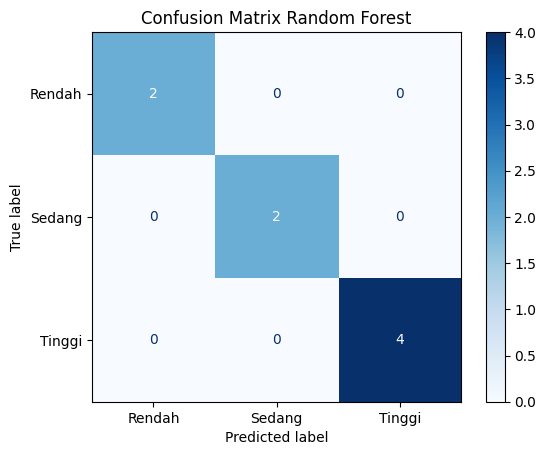

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,
    display_labels=['Rendah', 'Sedang', 'Tinggi']

)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix Random Forest")

plt.show()

In [ ]:
importance = pd.DataFrame({

    'Feature': features,
    'Importance': rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                     Feature  Importance
3  akses air minum layak (%)    0.296784
1        pemberian MPASI (%)    0.269889
0          pemberian ASI (%)    0.250188
4   akses sanitasi layak (%)    0.105461
2    Pemberian imunisasi (%)    0.077677


In [ ]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

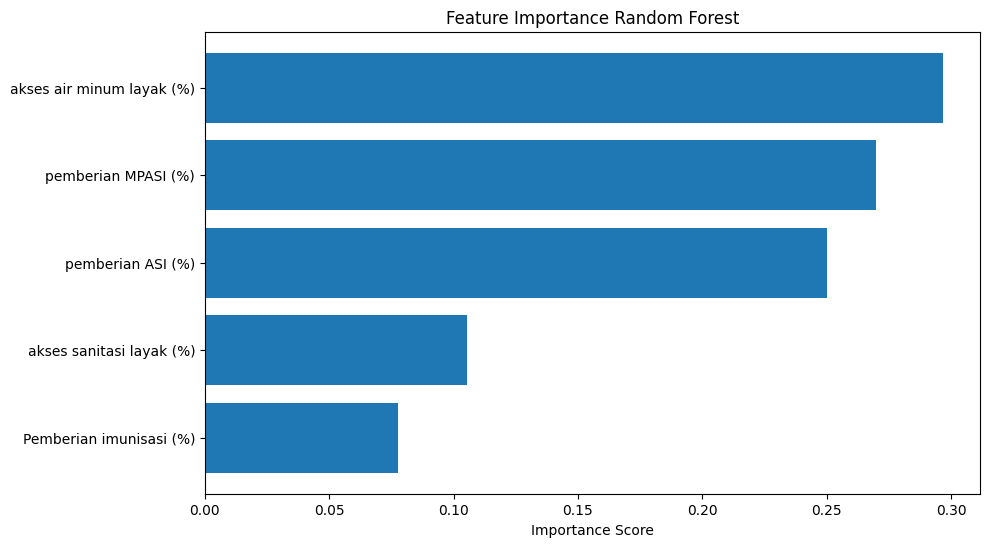

In [ ]:
# Visualisasi Feature Importance
plt.figure(figsize=(10,6))

plt.barh(

    importance['Feature'],
    importance['Importance']

)

plt.gca().invert_yaxis()

plt.title("Feature Importance Random Forest")

plt.xlabel("Importance Score")

plt.show()

In [ ]:
print(cluster_profile)

# 0 = Risiko Rendah
# 1 = Risiko Sedang
# 2 = Risiko Tinggi

         pemberian ASI (%)  pemberian MPASI (%)  Pemberian imunisasi (%)  \
cluster                                                                    
0                95.600000            89.075000                68.550000   
1                86.181818            65.909091                45.409091   
2                93.497076            77.136842                41.975146   

         akses air minum layak (%)  akses sanitasi layak (%)  
cluster                                                       
0                        95.575000                 71.087500  
1                        80.445455                 74.072727  
2                        88.134211                 80.506433  


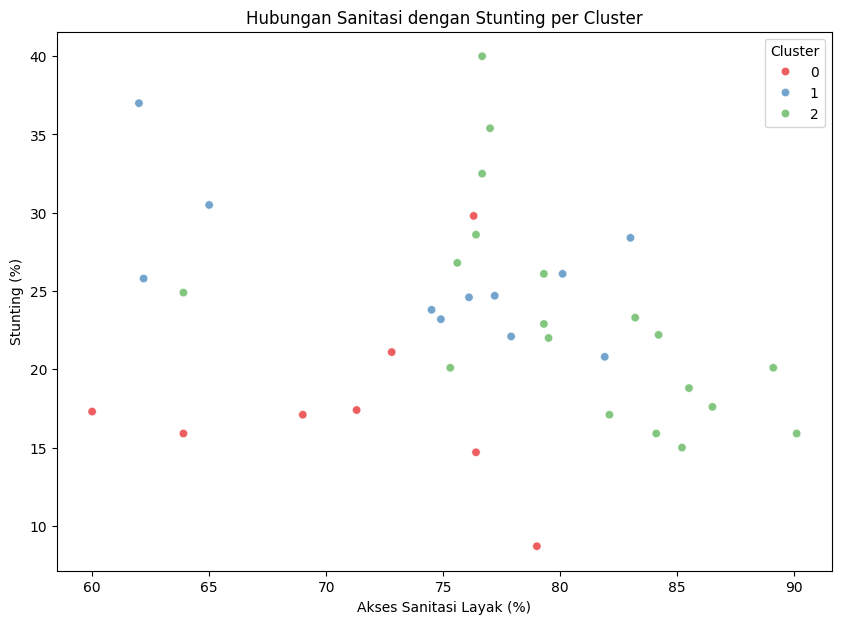

In [ ]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df,
    x='akses sanitasi layak (%)',
    y='Stunting (%)',
    hue='Cluster',
    palette='Set1',
    alpha=0.7
)

plt.title('Hubungan Sanitasi dengan Stunting per Cluster')
plt.xlabel('Akses Sanitasi Layak (%)')
plt.ylabel('Stunting (%)')
plt.show()

Scatter plot berdasarkan akses sanitasi menunjukkan bahwa provinsi dengan tingkat sanitasi rendah cenderung memiliki angka stunting yang tinggi. Hal ini terlihat dari kelompok provinsi yang masuk ke cluster risiko tinggi, ditandai dengan warna tertentu. Sebaliknya, provinsi dengan akses sanitasi lebih baik cenderung memiliki angka stunting lebih rendah dan masuk ke cluster risiko rendah. Namun, terlihat adanya overlap antar cluster, yang menunjukkan bahwa sanitasi bukan satu-satunya faktor penentu stunting. Faktor lain seperti pemberian ASI, MPASI, imunisasi, dan akses air minum juga berperan penting dalam membentuk pola risiko stunting antar provinsi.

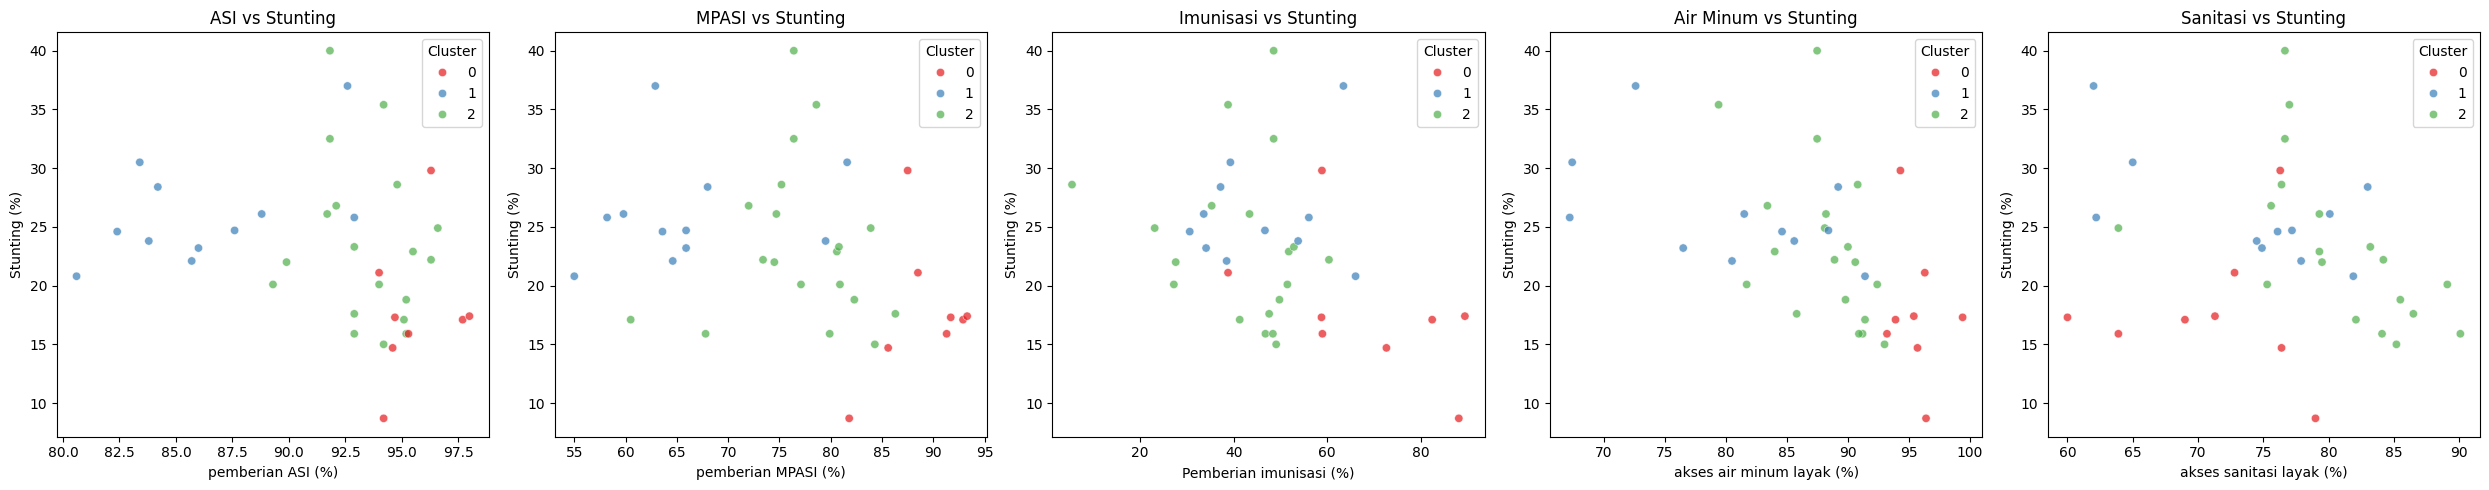

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(25,5))

# ASI vs Stunting
sns.scatterplot(
    data=df,
    x='pemberian ASI (%)',
    y='Stunting (%)',
    hue='Cluster',
    palette='Set1',
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('ASI vs Stunting')

# MPASI vs Stunting
sns.scatterplot(
    data=df,
    x='pemberian MPASI (%)',
    y='Stunting (%)',
    hue='Cluster',
    palette='Set1',
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('MPASI vs Stunting')

# Imunisasi vs Stunting
sns.scatterplot(
    data=df,
    x='Pemberian imunisasi (%)',
    y='Stunting (%)',
    hue='Cluster',
    palette='Set1',
    alpha=0.7,
    ax=axes[2]
)
axes[2].set_title('Imunisasi vs Stunting')

# Air Minum vs Stunting
sns.scatterplot(
    data=df,
    x='akses air minum layak (%)',
    y='Stunting (%)',
    hue='Cluster',
    palette='Set1',
    alpha=0.7,
    ax=axes[3]
)
axes[3].set_title('Air Minum vs Stunting')

# Sanitasi vs Stunting
sns.scatterplot(
    data=df,
    x='akses sanitasi layak (%)',
    y='Stunting (%)',
    hue='Cluster',
    palette='Set1',
    alpha=0.7,
    ax=axes[4]
)
axes[4].set_title('Sanitasi vs Stunting')

plt.tight_layout()
plt.show()

Secara keseluruhan, kelima variabel yaitu pemberian ASI, pemberian MPASI, imunisasi, akses air minum, dan akses sanitasi memiliki hubungan terhadap prevalensi stunting, namun hubungan tersebut tidak bersifat linear maupun sederhana. Pemberian ASI dan MPASI yang tinggi cenderung berkaitan dengan angka stunting yang lebih rendah, meskipun pada beberapa provinsi masih terlihat adanya kasus stunting meski cakupan gizi cukup baik. Hal ini menunjukkan bahwa intervensi gizi saja tidak cukup tanpa dukungan faktor kesehatan dan lingkungan. Sementara itu, cakupan imunisasi yang lebih tinggi tampak berhubungan dengan penurunan angka stunting, karena imunisasi membantu menjaga kesehatan anak dari penyakit yang dapat menghambat pertumbuhan. Di sisi lain, akses air minum dan sanitasi menunjukkan kecenderungan hubungan negatif yang lebih jelas: provinsi dengan kondisi lingkungan buruk lebih banyak ditemukan pada cluster dengan stunting tinggi. Dengan demikian, prevalensi stunting dipengaruhi oleh interaksi multidimensional antara faktor gizi, kesehatan, dan lingkungan, sehingga tidak dapat dijelaskan hanya oleh satu variabel saja.

📊 Kesimpulan Analisis

Clustering K-Means berhasil membagi provinsi ke dalam tiga kelompok risiko stunting: rendah, sedang, dan tinggi. Walaupun terlihat adanya pemisahan, masih terdapat overlap antar cluster, menandakan bahwa faktor stunting bersifat kompleks dan multidimensional.

Profil cluster menunjukkan bahwa provinsi dengan cakupan tinggi pada ASI, MPASI, imunisasi, akses air minum, dan sanitasi cenderung masuk ke cluster risiko rendah, sedangkan provinsi dengan cakupan rendah pada faktor-faktor tersebut lebih banyak masuk ke cluster risiko tinggi.

Visualisasi PCA dan scatter plot memperlihatkan pola hubungan yang konsisten: semakin rendah akses sanitasi dan air minum layak, semakin tinggi angka stunting. Korelasi tambahan juga terlihat antara indikator gizi seperti underweight dengan stunting, meskipun indikator tersebut bukan variabel inti dalam pembentukan cluster.

Random Forest Classification mencapai akurasi 100% pada data uji, menunjukkan model mampu memprediksi cluster dengan baik. Analisis feature importance mengungkap bahwa faktor paling berpengaruh adalah akses air minum layak (29,6%), diikuti pemberian MPASI (26,9%), ASI (25%), sanitasi (10,5%), dan imunisasi (7,7%).

🔑 Implikasi Kebijakan

Prioritas intervensi perlu difokuskan pada provinsi yang masuk cluster risiko tinggi, terutama dengan memperbaiki akses air minum layak dan sanitasi, karena hasil analisis menunjukkan kedua faktor lingkungan ini paling berpengaruh terhadap prevalensi stunting.

Program gizi seperti ASI eksklusif dan MPASI berkualitas harus diperkuat, karena kontribusinya hampir setara dengan faktor lingkungan dalam menurunkan risiko stunting.

Imunisasi tetap penting sebagai faktor pendukung kesehatan anak, meskipun kontribusinya relatif lebih kecil dibandingkan faktor gizi dan lingkungan.

Pendekatan multidimensi diperlukan: kebijakan tidak bisa hanya fokus pada satu variabel, melainkan harus mengintegrasikan intervensi gizi, kesehatan, dan lingkungan secara bersamaan.